In [2]:
import time
import math
import copy
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.metrics import classification_report, accuracy_score
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, Subset, TensorDataset, random_split
from torchsummary import summary

In [3]:
# Define CIFAR-10 mean and std for data normalization.
cifar_mean = [0.4914, 0.4822, 0.4465]
cifar_std  = [0.2023, 0.1994, 0.2010]

# Apply Data Augmentation (Flip, Crop)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std)
])

# Evaluation transforms (Validation/Test): use only normalization
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std)
])

# Load the full training set with the training transforms applied
full_train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

# Reload the training set with "clean" transforms so it can be used for the split
full_train_clean = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=val_test_transform
)

# Load the test set
testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=val_test_transform
)

# Training/Validation split (80/20)

dataset_size = len(full_train_dataset)      # 50,000 images
train_size = int(0.8 * dataset_size)        # 40,000 for training
val_size = dataset_size - train_size        # 10,000 for validation

# Use a generator with a fixed seed (42) to ensure split reproducibility
generator = torch.Generator().manual_seed(42)
indices = torch.randperm(dataset_size, generator=generator)

# Define the indices for each subset.
train_indices = indices[:train_size]
val_indices = indices[train_size:]

# Create the final subsets:
train_subset = Subset(full_train_dataset, train_indices)
val_subset = Subset(full_train_clean, val_indices)

print(f"Train size: {len(train_subset)} | Val size: {len(val_subset)} | Test size: {len(testset)}")

BATCH_SIZE = 256
NUM_WORKERS = 2

# Training loader with shuffle
trainloader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# Validation loader without shuffle
validationloader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# Test loader
testloader = DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"✅ DataLoaders ready. Batch size: {BATCH_SIZE}, Workers: {NUM_WORKERS}")


Train size: 40000 | Val size: 10000 | Test size: 10000
✅ DataLoaders ready. Batch size: 256, Workers: 2


In [4]:
# Function for computing ECE
def compute_ece(logits, labels, n_bins=15):
    probs = torch.softmax(logits, dim=1)
    confidences, predictions = probs.max(dim=1)
    accuracies = predictions.eq(labels)

    ece = torch.zeros(1, device=logits.device)
    bin_size = 1.0 / n_bins

    for i in range(n_bins):
        lower = i * bin_size
        upper = (i + 1) * bin_size
        mask = (confidences > lower) & (confidences <= upper)
        if mask.any():
            acc_bin = accuracies[mask].float().mean()
            conf_bin = confidences[mask].mean()
            ece += mask.float().mean() * torch.abs(acc_bin - conf_bin)
    return ece.item()


In [5]:
# CNN model
class CNNclassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # BLOCK 1 (3 -> 64)
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),        # Image: 32x32 -> 16x16
            nn.Dropout(0.25)
        )

        # BLOCK 2 (64 -> 128)
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),        # Image: 16x16 -> 8x8
            nn.Dropout(0.25)
        )

        # BLOCK 3 (128 -> 256)
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.MaxPool2d(2),        # Image: 8x8 -> 4x4
            nn.Dropout(0.4)
        )

        # -------- CLASSIFIER --------
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256), # Convert to a vector (256*4*4)
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def _init_weights(self): # Weight initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                fan_in = m.in_channels if isinstance(m, nn.Conv2d) else m.in_features
                fan_out = m.out_channels if isinstance(m, nn.Conv2d) else m.out_features
                b = math.sqrt(6) / math.sqrt(fan_in + fan_out)
                nn.init.uniform_(m.weight, -b, b)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.0)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


In [6]:
# Training setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNclassifier().to(device)
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)
# optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

# Training parameters
num_epochs = 100
patience = 5 # Early Stopping limit
best_loss = float('inf')
counter = 0
best_model = None

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print(f"✅ Device: {device}")
total_start = time.time()

# Training loop
for epoch in range(num_epochs):
    epoch_start = time.time()
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in trainloader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad() # Reset gradients from the previous batch
        outputs = model(images) # Forward pass
        loss = criterion(outputs, labels) # Loss computation
        loss.backward() # Backpropagation
        optimizer.step() # Update weights
        running_loss += loss.item()
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    # Compute the average Loss and Accuracy for the epoch
    train_loss = running_loss / len(trainloader)
    train_acc = 100.0 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # --- Validation ---
    model.eval() # Without Dropout
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad(), torch.amp.autocast('cuda'): # torch.no_grad(): gradients are not computed during validation
        for X, y in validationloader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            loss = criterion(outputs, y)
            val_loss += loss.item()
            _, preds = outputs.max(1)
            total_val += y.size(0)
            correct_val += (preds == y).sum().item()

    val_loss /= len(validationloader)
    val_acc = 100.0 * correct_val / total_val
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    scheduler.step(val_loss)

    epoch_time = time.time() - epoch_start

    print(f"Epoch [{epoch+1}/{num_epochs}] - "
          f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.2f}% | "
          f"🕒 Time: {epoch_time:.2f}s")

    # Early stopping
    if val_loss < best_loss: # If a new lower validation loss is found, save the model
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict()) # Copy of the weights
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"⏹️ Early stopping at epoch {epoch+1}! Best Val Loss: {best_loss:.4f}")
            break

total_time = time.time() - total_start
print(f"
✅ Training completed in {total_time/60:.2f} minutes ({total_time:.1f}s).")


✅ Device: cuda
✅ Device: cuda
Epoch [1/100] - Train Loss: 1.6298 - Train Acc: 39.83% | Val Loss: 1.3407 - Val Acc: 50.42% | 🕒 Time: 28.61s
Epoch [2/100] - Train Loss: 1.2415 - Train Acc: 55.09% | Val Loss: 1.0988 - Val Acc: 60.52% | 🕒 Time: 27.41s
Epoch [3/100] - Train Loss: 1.0536 - Train Acc: 62.25% | Val Loss: 0.9238 - Val Acc: 66.61% | 🕒 Time: 28.49s
Epoch [4/100] - Train Loss: 0.9361 - Train Acc: 66.82% | Val Loss: 0.8793 - Val Acc: 69.09% | 🕒 Time: 27.13s
Epoch [5/100] - Train Loss: 0.8498 - Train Acc: 70.09% | Val Loss: 0.7670 - Val Acc: 73.04% | 🕒 Time: 27.90s
Epoch [6/100] - Train Loss: 0.7892 - Train Acc: 72.36% | Val Loss: 0.7470 - Val Acc: 74.06% | 🕒 Time: 27.52s
Epoch [7/100] - Train Loss: 0.7365 - Train Acc: 74.23% | Val Loss: 0.7212 - Val Acc: 74.93% | 🕒 Time: 30.26s
Epoch [8/100] - Train Loss: 0.6977 - Train Acc: 75.50% | Val Loss: 0.6165 - Val Acc: 78.11% | 🕒 Time: 28.16s
Epoch [9/100] - Train Loss: 0.6603 - Train Acc: 76.90% | Val Loss: 0.5956 - Val Acc: 79.25% | 🕒 Ti

✅ Test Loss: 0.3027 | Test Accuracy: 89.75%
🔵 Expected Calibration Error (ECE): 0.0250


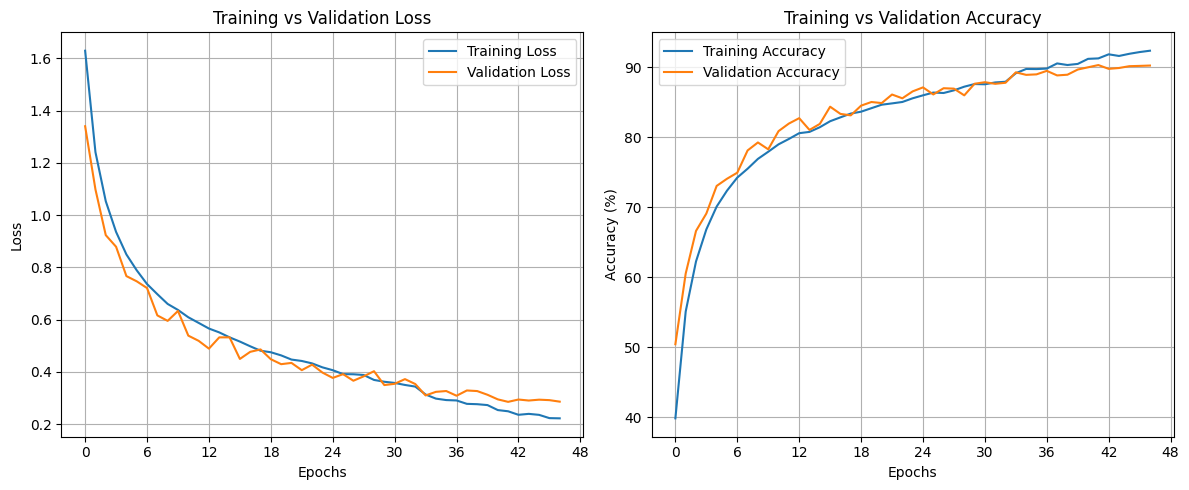

In [7]:
# Evaluation
# Load the best model (from Early Stopping)
model.load_state_dict(best_model)
model.eval()
test_loss, correct, total = 0.0, 0, 0
all_logits = []
all_labels = []

with torch.no_grad():
    for X, y in testloader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)          # logits
        loss = criterion(outputs, y)
        test_loss += loss.item()

        _, preds = outputs.max(1)
        total += y.size(0)
        correct += (preds == y).sum().item()

        # logits + labels for ECE computation
        all_logits.append(outputs)
        all_labels.append(y)

# Concatenate
all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels)

avg_loss = test_loss / len(testloader)
accuracy = 100.0 * correct / total

ece = compute_ece(all_logits, all_labels)
print(f"✅ Test Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")
print(f"🔵 Expected Calibration Error (ECE): {ece:.4f}")

# Plots
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title('Training vs Validation Loss'); plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# Accuracy
plt.subplot(1,2,2)
plt.plot(train_accs, label='Training Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epochs'); plt.ylabel('Accuracy (%)'); plt.title('Training vs Validation Accuracy'); plt.legend()
plt.grid(True) # Optional, helps readability
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()


In [ ]:
# Visualization function
def imshow(img, mean, std):
    img = img.clone()
    # Reverse normalization
    for i in range(3):
        img[i] = img[i] * std[i] + mean[i]
    img = img.numpy()
    plt.imshow(np.transpose(img, (1, 2, 0)))

classes = ('Plane', 'Car', 'Bird', 'Cat', 'Deer',
           'Dog', 'Frog', 'Horse', 'Ship', 'Truck')

# Get one data batch
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Predictions
outputs = model(images)
_, preds = torch.max(outputs, 1)

# Separate correct and incorrect predictions
correct_indices = (preds == labels).nonzero(as_tuple=True)[0]
incorrect_indices = (preds != labels).nonzero(as_tuple=True)[0]

plt.figure(figsize=(10, 8))

# 5 correct examples
print("✅ Correct Classification Examples:")
for i in range(5):
    if i >= len(correct_indices): break
    idx = correct_indices[i]

    ax = plt.subplot(2, 5, i + 1)
    imshow(images[idx].cpu(), cifar_mean, cifar_std)
    ax.set_title(f"T:{classes[labels[idx]]}
P:{classes[preds[idx]]}", color="green")
    ax.axis('off')

# 5 incorrect examples
print("
❌ Incorrect Classification Examples:")
for i in range(5):
    if i >= len(incorrect_indices): break
    idx = incorrect_indices[i]

    ax = plt.subplot(2, 5, i + 6)
    imshow(images[idx].cpu(), cifar_mean, cifar_std)
    ax.set_title(f"True:{classes[labels[idx]]}
Pred:{classes[preds[idx]]}", color="red")
    ax.axis('off')

plt.tight_layout()
plt.show()
